# Expected Loss Modeling for Credit Risk (PD × LGD × EAD)

## Goal
Estimate the expected financial loss of each borrower by combining predicted default risk with proxy estimates of loss severity and exposure.

## Business Impact
Enables risk-based lending decisions by prioritizing applicants based on expected financial loss rather than binary classification, improving portfolio profitability and capital allocation.

## Approach
- Built a Probability of Default (PD) model using Logistic Regression and XGBoost, optimized using ROC-AUC and Precision-Recall
- Estimated Loss Given Default (LGD) using a rule-based proxy derived from credit utilization and debt burden, due to absence of recovery data
- Approximated Exposure at Default (EAD) using income-based proxies to represent borrower exposure capacity
- Computed Expected Loss = PD × LGD × EAD
- Designed decision thresholds based on minimizing total expected loss, instead of maximizing classification metrics

## Evaluation
- PD model evaluated using ROC-AUC, PR-AUC, Precision, Recall, and F1-score
- Compared decision thresholds using:
    - Classification metrics
    - Total expected loss
- Analyzed distribution of expected loss across borrower segments

## Key Insight
Thresholds optimized for expected loss produce more financially efficient lending decisions than thresholds based purely on classification accuracy.

## Limitations
- LGD and EAD are proxy estimates, not derived from actual recovery and exposure data
- Results are directionally valid but not production-ready
- Real-world deployment requires:
    - Historical recovery data for LGD modeling
    - Actual credit line / loan exposure for EAD
    - Calibration and backtesting

### Ignore warnings

In [57]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### Importing libraries

In [58]:
import pandas as pd
import numpy as np

### Load the dataset

In [59]:
df = pd.read_csv('cs-training.csv')

In [60]:
df.shape

(150000, 12)

In [61]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### Data structure diagnosis

In [62]:
def simple_inspect(df):
    summary = []  # store results for each column

    for col in df.columns:
        s = df[col]  # current column
        nonnull = s.dropna()  # remove missing values

        # sample up to 10 unique values (for quick inspection)
        sample_vals = [str(x)[:30] for x in nonnull.unique()[:10]]

        # % of missing values
        missing_pct = round(s.isna().mean() * 100, 2)

        # number of unique values (excluding NaN)
        unique_vals = s.nunique(dropna=True)

        # initialize stats
        min_val = None
        max_val = None
        skewness = None

        # compute stats only for numeric columns
        if pd.api.types.is_numeric_dtype(s) and len(nonnull) > 0:
            min_val = nonnull.min()
            max_val = nonnull.max()

            # skewness requires at least 3 values
            if len(nonnull) > 2:
                skewness = round(nonnull.skew(), 3)

        # store results
        summary.append({
            "Column": col,
            "Sample Values": sample_vals,
            "Dtype": str(s.dtype),
            "Missing %": missing_pct,
            "Unique": unique_vals,
            "Min": min_val,
            "Max": max_val,
            "Skewness": skewness
        })

    # return as DataFrame for easy viewing
    return pd.DataFrame(summary)


# run inspection
inspect_df = simple_inspect(df)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,Unnamed: 0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",int64,0.00,150000,1.0,150000.0,-0.000
1,SeriousDlqin2yrs,"[1, 0]",int64,0.00,2,0.0,1.0,3.469
2,RevolvingUtilizationOfUnsecuredLines,"[0.766126609, 0.957151019, 0.65818014, 0.23380...",float64,0.00,125728,0.0,50708.0,97.632
3,age,"[45, 40, 38, 30, 49, 74, 57, 39, 27, 51]",int64,0.00,86,0.0,109.0,0.189
4,NumberOfTime30-59DaysPastDueNotWorse,"[2, 0, 1, 3, 4, 5, 7, 10, 6, 98]",int64,0.00,16,0.0,98.0,22.597
5,DebtRatio,"[0.802982129, 0.121876201, 0.085113375, 0.0360...",float64,0.00,114194,0.0,329664.0,95.158
6,MonthlyIncome,"[9120.0, 2600.0, 3042.0, 3300.0, 63588.0, 3500...",float64,19.82,13594,0.0,3008750.0,114.040
7,NumberOfOpenCreditLinesAndLoans,"[13, 4, 2, 5, 7, 3, 8, 9, 6, 10]",int64,0.00,58,0.0,58.0,1.215
8,NumberOfTimes90DaysLate,"[0, 1, 3, 2, 5, 4, 98, 10, 9, 6]",int64,0.00,19,0.0,98.0,23.087
9,NumberRealEstateLoansOrLines,"[6, 0, 1, 3, 4, 2, 5, 8, 7, 9]",int64,0.00,28,0.0,54.0,3.482


### Data dictionary

| Feature                                  | Meaning                                            | Type         | How to interpret                          |
| ---------------------------------------- | -------------------------------------------------- | ------------ | ----------------------------------------- |
| **SeriousDlqin2yrs**                     | Target: whether borrower defaulted in next 2 years | Binary (0/1) | 1 = default, 0 = no default               |
| **RevolvingUtilizationOfUnsecuredLines** | % of credit used (credit cards, personal lines)    | Continuous   | Higher = more risk (overleveraged)        |
| **age**                                  | Borrower age                                       | Numeric      | Younger borrowers often riskier (depends) |
| **NumberOfTime30-59DaysPastDueNotWorse** | # of times late 30–59 days                         | Count        | Early delinquency signal                  |
| **DebtRatio**                            | Monthly debt / income                              | Continuous   | Higher = more financial stress            |
| **MonthlyIncome**                        | Monthly income                                     | Continuous   | Lower income = higher risk (generally)    |
| **NumberOfOpenCreditLinesAndLoans**      | Total active credit accounts                       | Count        | Too high or too low can be risky          |
| **NumberOfTimes90DaysLate**              | # of times late ≥90 days                           | Count        | Strong default signal (VERY important)    |
| **NumberRealEstateLoansOrLines**         | # of mortgages / real estate loans                 | Count        | Proxy for asset ownership                 |
| **NumberOfTime60-89DaysPastDueNotWorse** | # of times late 60–89 days                         | Count        | Mid-stage delinquency                     |
| **NumberOfDependents**                   | # of dependents                                    | Count        | Higher = more financial burden            |


### Feature type groupings

In [63]:
datetime_cols = [
]

categorical_cols = [
]

ordinal_cols = [
]

numerical_cols = [
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents"
]

skewed_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome"
]

missing_numerical_cols = [
    "MonthlyIncome",
    "NumberOfDependents"
]

missing_categorical_cols = [
]

drop_cols = [
    "Unnamed: 0"
]

target_col = "SeriousDlqin2yrs"

### Map target column

### Feature type conversion

In [64]:
# drop unnecessary columns
df = df.drop(columns=drop_cols, errors="ignore")

# convert categorical columns to category dtype
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# convert ordinal + numerical + skewed columns to numeric
# errors="coerce" → invalid values become NaN
for col in ordinal_cols + numerical_cols + skewed_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# convert datetime columns to datetime format
# errors="coerce" → invalid dates become NaN
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# check final data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

### Removing duplicates

In [65]:
before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print("Removed rows:", before - after)

Removed rows: 609


### Exploratory data analysis

In [66]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

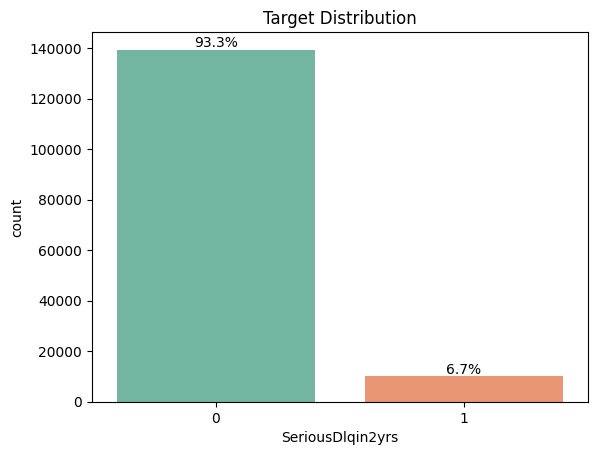

In [67]:
plt.figure()
ax = sns.countplot(x=target_col, data=df, palette="Set2")

# total count for percentage
total = len(df)

# add labels
for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total
    ax.annotate(f'{percent:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Target Distribution")
plt.show()

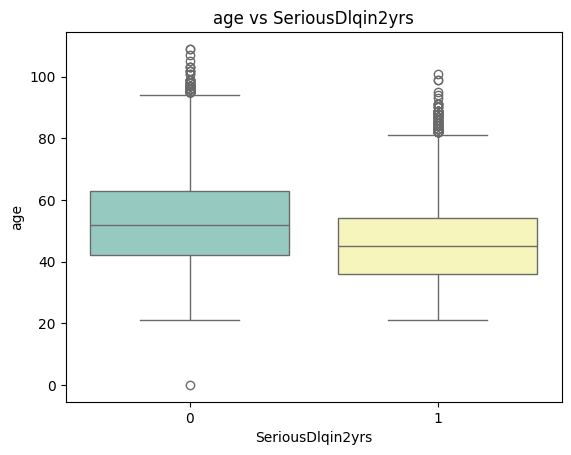

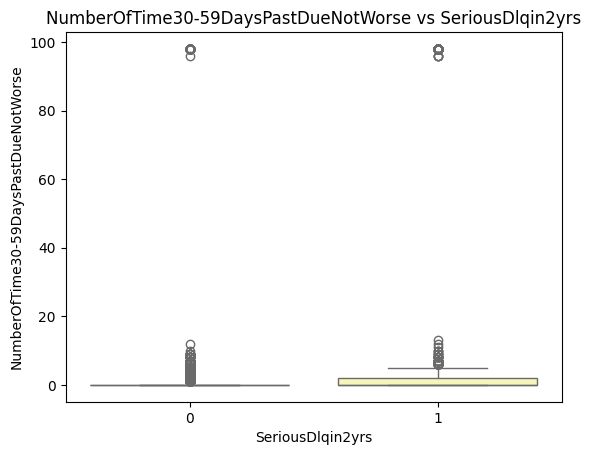

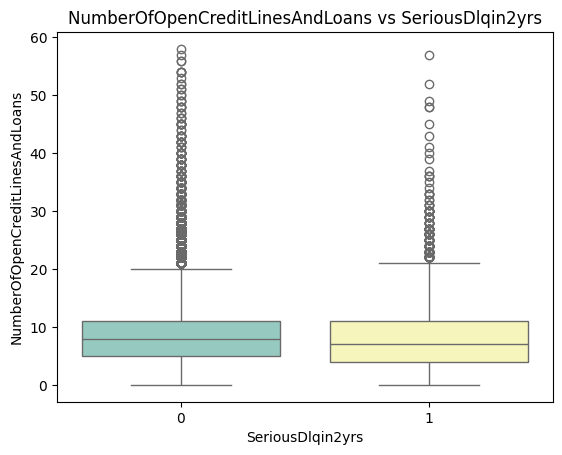

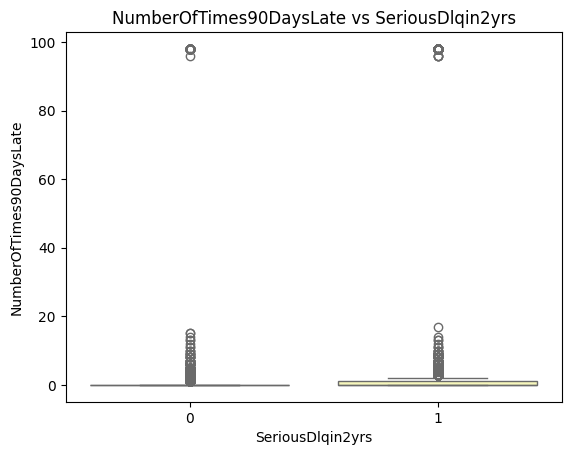

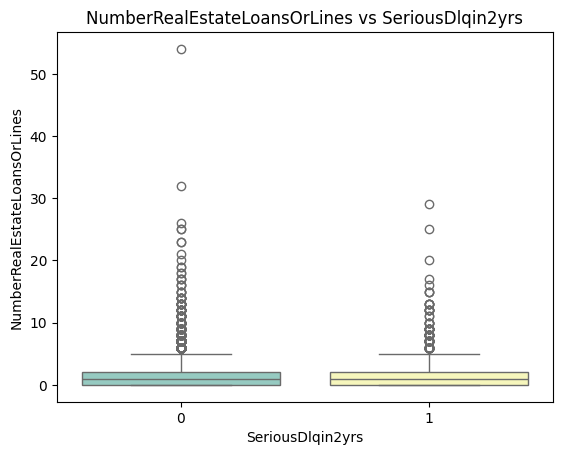

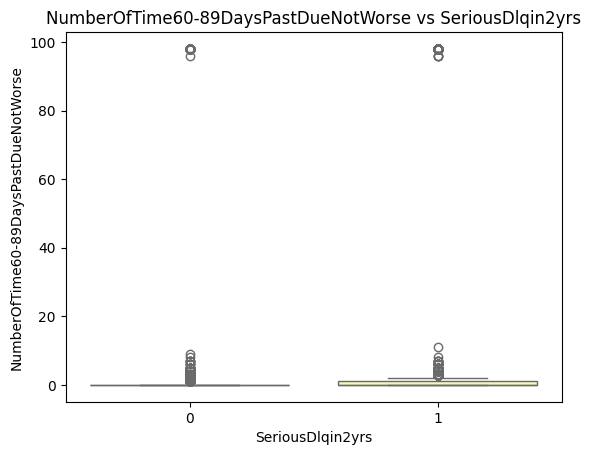

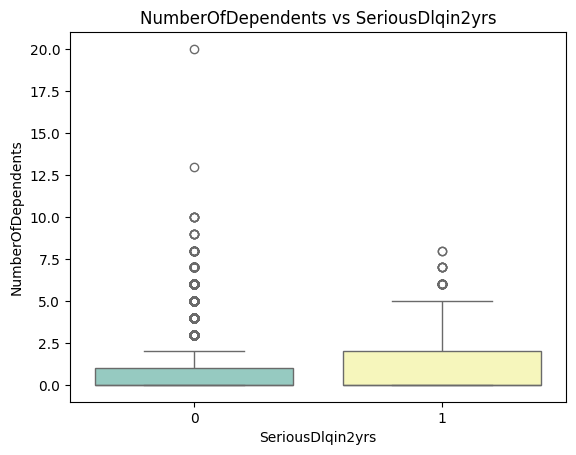

In [68]:
# loop through each numerical feature
for col in numerical_cols:
    
    plt.figure()  # create a new plot for each feature
    
    # boxplot: compare distribution of feature across target classes (0 vs 1)
    sns.boxplot(x=target_col, y=col, data=df, palette="Set3")
    
    # set plot title
    plt.title(f"{col} vs {target_col}")
    
    plt.show()  # display the plot

In [69]:
# loop through categorical and ordinal features
for col in categorical_cols + ordinal_cols:
    
    # print section header for readability
    print(f"\n=== {col} vs {target_col} ===")
    
    # create cross-tab:
    # rows = categories, columns = target (0/1)
    # normalize="index" → proportions per category (row-wise)
    ct = pd.crosstab(df[col], df[target_col], normalize="index")
    
    # plot stacked bar chart (shows distribution of target within each category)
    ct.plot(kind="bar", stacked=True)
    
    # set title and label
    plt.title(f"{col} vs {target_col}")
    plt.ylabel("Proportion")
    
    plt.show()  # display plot

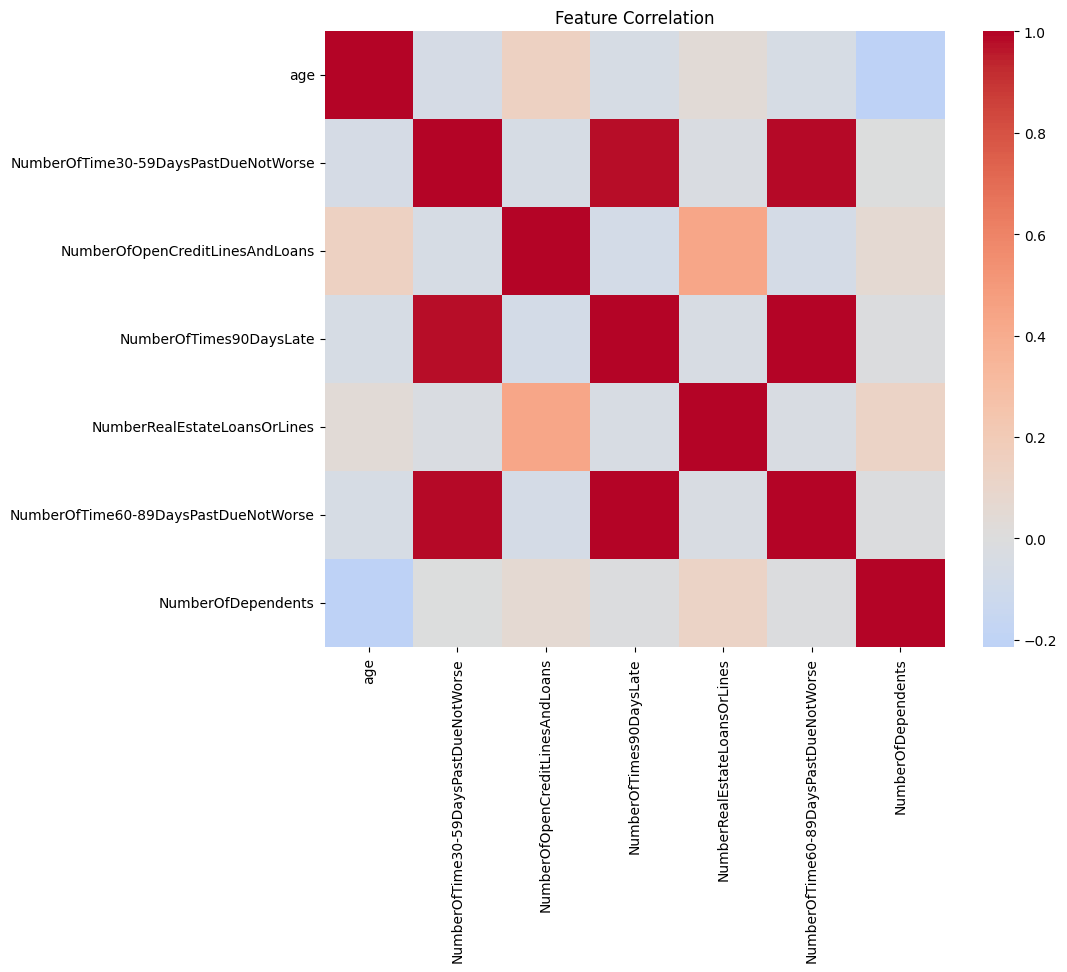

In [70]:
# compute correlation matrix for numerical features
corr = df[numerical_cols].corr()

# create figure with size
plt.figure(figsize=(10,8))

# heatmap:
# cmap="coolwarm" → blue (negative), red (positive)
# center=0 → center color at zero correlation
sns.heatmap(corr, cmap="coolwarm", center=0)

# title of the plot
plt.title("Feature Correlation")

# display the heatmap
plt.show()

### Feature engineering

In [71]:
# create a weighted delinquency score
# combines frequency + severity of late payments
df['delinquency_score'] = (
    1 * df['NumberOfTime30-59DaysPastDueNotWorse'] +   # mild lateness
    2 * df['NumberOfTime60-89DaysPastDueNotWorse'] +   # moderate lateness
    3 * df['NumberOfTimes90DaysLate']                  # severe lateness
)

### Converted data structure diagnosis

In [72]:
inspect_df = simple_inspect(df)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,SeriousDlqin2yrs,"[1, 0]",int64,0.00,2,0.0,1.0,3.464
1,RevolvingUtilizationOfUnsecuredLines,"[0.766126609, 0.957151019, 0.65818014, 0.23380...",float64,0.00,125728,0.0,50708.0,97.433
2,age,"[45, 40, 38, 30, 49, 74, 57, 39, 27, 51]",int64,0.00,86,0.0,109.0,0.192
3,NumberOfTime30-59DaysPastDueNotWorse,"[2, 0, 1, 3, 4, 5, 7, 10, 6, 98]",int64,0.00,16,0.0,98.0,24.475
4,DebtRatio,"[0.802982129, 0.121876201, 0.085113375, 0.0360...",float64,0.00,114194,0.0,329664.0,94.980
5,MonthlyIncome,"[9120.0, 2600.0, 3042.0, 3300.0, 63588.0, 3500...",float64,19.56,13594,0.0,3008750.0,114.017
6,NumberOfOpenCreditLinesAndLoans,"[13, 4, 2, 5, 7, 3, 8, 9, 6, 10]",int64,0.00,58,0.0,58.0,1.222
7,NumberOfTimes90DaysLate,"[0, 1, 3, 2, 5, 4, 98, 10, 9, 6]",int64,0.00,19,0.0,98.0,25.107
8,NumberRealEstateLoansOrLines,"[6, 0, 1, 3, 4, 2, 5, 8, 7, 9]",int64,0.00,28,0.0,54.0,3.485
9,NumberOfTime60-89DaysPastDueNotWorse,"[0, 1, 2, 5, 3, 98, 4, 6, 7, 8]",int64,0.00,13,0.0,98.0,25.424


### Separate X and y variable

In [73]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [74]:
print(X.shape)
print(y.shape)
print(y.value_counts(normalize=True))

(149391, 11)
(149391,)
SeriousDlqin2yrs
0    0.933001
1    0.066999
Name: proportion, dtype: float64


### Train-Validation-Test Split


In [75]:
from sklearn.model_selection import train_test_split

# first split:
# 70% train, 30% temporary (to be split into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,          # 30% goes to temp
    random_state=42,        # ensures reproducibility
    stratify=y              # keeps class distribution consistent
)

# second split:
# split the 30% temp into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,          # split temp equally → 15% val, 15% test
    random_state=42,
    stratify=y_temp         # maintain class balance
)

X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

In [76]:
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Train: SeriousDlqin2yrs
0    0.933004
1    0.066996
Name: proportion, dtype: float64
Val: SeriousDlqin2yrs
0    0.932973
1    0.067027
Name: proportion, dtype: float64
Test: SeriousDlqin2yrs
0    0.933018
1    0.066982
Name: proportion, dtype: float64


### Handling Missing Values

In [77]:
# 1. Create missing flags (before imputation)
# mark where values were originally missing (useful signal for model)
for col in missing_numerical_cols:
    X_train[f"{col}_missing"] = X_train[col].isna().astype(int)
    X_val[f"{col}_missing"] = X_val[col].isna().astype(int)
    X_test[f"{col}_missing"] = X_test[col].isna().astype(int)

# 2. Compute medians (train only)
# use only training data to avoid data leakage
medians = X_train[missing_numerical_cols].median()

# 3. Impute missing values (apply same medians to all splits)
X_train[missing_numerical_cols] = X_train[missing_numerical_cols].fillna(medians)
X_val[missing_numerical_cols] = X_val[missing_numerical_cols].fillna(medians)
X_test[missing_numerical_cols] = X_test[missing_numerical_cols].fillna(medians)

In [78]:
print(X_train[missing_numerical_cols].isna().sum())
print(X_val[missing_numerical_cols].isna().sum())
print(X_test[missing_numerical_cols].isna().sum())

MonthlyIncome         0
NumberOfDependents    0
dtype: int64
MonthlyIncome         0
NumberOfDependents    0
dtype: int64
MonthlyIncome         0
NumberOfDependents    0
dtype: int64


### Log transform skewed data

In [79]:
log_cols = []  # store names of new log-transformed columns

for col in skewed_cols:
    new_col = f"{col}_log"
    
    # apply log transform (log1p handles zeros safely)
    # clip(lower=0) → avoids issues if negative values exist
    X_train[new_col] = np.log1p(X_train[col].clip(lower=0))
    X_val[new_col]   = np.log1p(X_val[col].clip(lower=0))
    X_test[new_col]  = np.log1p(X_test[col].clip(lower=0))
    
    # save new column name
    log_cols.append(new_col)

# drop original skewed columns (only keep log versions)
X_train = X_train.drop(columns=skewed_cols)
X_val   = X_val.drop(columns=skewed_cols)
X_test  = X_test.drop(columns=skewed_cols)

# check distribution of transformed features
display(X_train[log_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines_log,104573.0,0.257961,0.388562,0.0,0.029707,0.143507,0.442995,10.833859
DebtRatio_log,104573.0,1.534100,2.634770,0.0,0.162500,0.313183,0.626759,12.705832
MonthlyIncome_log,104573.0,8.451929,1.186580,0.0,8.273081,8.594339,8.911530,14.917036


### Encoding categorical features

In [80]:
# one-hot encode categorical variables
# drop_first=True → removes one category per feature (for LR to avoid multicollinearity)
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True, dtype=int)
X_val   = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True, dtype=int)
X_test  = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True, dtype=int)

# align validation and test columns to match training set
# ensures same feature space (important for model input)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# preview processed training data
display(X_train.head())

,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,delinquency_score,MonthlyIncome_missing,NumberOfDependents_missing,RevolvingUtilizationOfUnsecuredLines_log,DebtRatio_log,MonthlyIncome_log
108205,57,0,6,0,1,0,0.0,0,1,0,0.014776,7.664816,8.594339
83952,82,0,5,0,0,0,0.0,0,0,0,0.033189,0.000952,9.259226
136783,67,0,26,0,1,0,0.0,0,0,0,0.009132,0.336358,7.824446
111403,59,0,4,0,0,0,0.0,0,0,0,0.032824,0.085017,8.443116
38577,55,0,8,0,0,0,0.0,0,0,0,0.203761,0.495882,7.618742


### Scaling numerical features

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # initialize scaler

# scale numerical + log features
# fit ONLY on training data (to avoid data leakage)
X_train[numerical_cols + log_cols] = scaler.fit_transform(
    X_train[numerical_cols + log_cols]
)

# apply same scaling to validation and test sets
X_val[numerical_cols + log_cols] = scaler.transform(
    X_val[numerical_cols + log_cols]
)
X_test[numerical_cols + log_cols] = scaler.transform(
    X_test[numerical_cols + log_cols]
)

# check scaled feature statistics (mean ~0, std ~1)
display(X_train.head())

,age,NumberOfTime30-59DaysPastDueNotWorse,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,delinquency_score,MonthlyIncome_missing,NumberOfDependents_missing,RevolvingUtilizationOfUnsecuredLines_log,DebtRatio_log,MonthlyIncome_log
108205,0.316476,-0.102843,-0.483126,-0.061446,-0.017484,-0.054665,-0.666589,0,1,0,-0.625863,2.326862,0.120018
83952,2.014058,-0.102843,-0.677370,-0.061446,-0.900722,-0.054665,-0.666589,0,0,0,-0.578475,-0.581894,0.680359
136783,0.995509,-0.102843,3.401769,-0.061446,-0.017484,-0.054665,-0.666589,0,0,0,-0.640387,-0.454593,-0.528819
111403,0.452283,-0.102843,-0.871615,-0.061446,-0.900722,-0.054665,-0.666589,0,0,0,-0.579413,-0.549987,-0.007428
38577,0.180670,-0.102843,-0.094636,-0.061446,-0.900722,-0.054665,-0.666589,0,0,0,-0.139489,-0.394047,-0.702179


### Model selection

In [ ]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier

# class imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# base models
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# parameter grids
lr_param_grid = {
    "C": [0.1, 1, 10]
}

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

# grid searches
models = {
    "Logistic Regression": GridSearchCV(
        estimator=lr,
        param_grid=lr_param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    ),
    "XGBoost": GridSearchCV(
        estimator=xgb,
        param_grid=xgb_param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )
}

# threshold candidates
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

best_model = None
best_model_name = None
best_threshold = None
best_score = -1

# train and validate each model
for name, search in models.items():
    start = time.time()

    # fit on training set
    search.fit(X_train, y_train)
    model = search.best_estimator_

    # predict probabilities on validation set
    y_val_proba = model.predict_proba(X_val)[:, 1]

    # find best threshold using F1 on validation set
    best_t = 0.5
    best_f1 = 0

    for t in thresholds:
        y_pred = (y_val_proba >= t).astype(int)
        f1 = f1_score(y_val, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    # final validation predictions using best threshold
    y_pred_final = (y_val_proba >= best_t).astype(int)

    precision = precision_score(y_val, y_pred_final, zero_division=0)
    recall = recall_score(y_val, y_pred_final, zero_division=0)
    f1_final = f1_score(y_val, y_pred_final, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_val_proba)
    pr_auc = average_precision_score(y_val, y_val_proba)
    runtime = time.time() - start

    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Best Threshold": round(best_t, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1_final,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Runtime (s)": runtime
    })

    print(f"\n{name}")
    print("Best Params:", search.best_params_)
    print("Best Threshold:", round(best_t, 2))
    print("F1:", round(f1_final, 4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("PR-AUC:", round(pr_auc, 4))

    # keep best model based on ROC-AUC
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = model
        best_model_name = name
        best_threshold = best_t

# results table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

print("\nModel Comparison:")
display(results_df)

print("\nFINAL CHOICE")
print("Best Model     :", best_model_name)
print("Best Threshold :", round(best_threshold, 2))
print("Best ROC-AUC   :", round(best_score, 4))


Logistic Regression
Best Params: {'C': 0.1}
Best Threshold: 0.7
F1: 0.4051
ROC-AUC: 0.8478
PR-AUC: 0.3384

XGBoost
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best Threshold: 0.8
F1: 0.4507
ROC-AUC: 0.8674
PR-AUC: 0.4025

Model Comparison:


,Model,Best Params,Best Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,Runtime (s)
1,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.8,0.411668,0.498003,0.450738,0.867411,0.402486,3.703563
0,Logistic Regression,{'C': 0.1},0.7,0.353320,0.474700,0.405114,0.847805,0.338396,2.345685



FINAL CHOICE
Best Model     : XGBoost
Best Threshold : 0.8
Best ROC-AUC   : 0.8674


### Run final evaluation on the test set

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# 1. Lock final model and threshold
final_model = best_model
final_threshold = best_threshold

print("Locked Final Model     :", best_model_name)
print("Locked Final Threshold :", round(final_threshold, 2))
print("Locked Best Params     :", final_model.get_params())

# 2. Use test set
# same processed test data for both models
X_test_final = X_test

# 3. Predict on TEST set
# predicted probabilities for positive class
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

# convert probabilities to class predictions using locked threshold
y_test_pred = (y_test_proba >= final_threshold).astype(int)

# 4. Compute test metrics
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("\nFINAL TEST RESULTS")
print("Test Precision :", round(test_precision, 4))
print("Test Recall    :", round(test_recall, 4))
print("Test F1 Score  :", round(test_f1, 4))
print("Test ROC-AUC   :", round(test_roc_auc, 4))
print("Test PR-AUC    :", round(test_pr_auc, 4))

# show target distribution for context
print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index())

# 5. Detailed classification results
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

# labeled confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

print("\nTest Confusion Matrix:")
display(cm_df)

# 6. Save final metrics in a table
final_test_results = pd.DataFrame([{
    "Model": best_model_name,
    "Threshold": round(final_threshold, 2),
    "Precision": test_precision,
    "Recall": test_recall,
    "F1 Score": test_f1,
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc
}])

display(final_test_results)

Locked Final Model     : XGBoost
Locked Final Threshold : 0.8
Locked Best Params     : {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': np.float64(13.926206109049387), 'subsample': None, 'tree_method': None, 'validate_p

,Pred 0,Pred 1
Actual 0,19903,1005
Actual 1,768,733


,Model,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.8,0.421749,0.488341,0.452609,0.866184,0.402698


### SHAP for interpretability

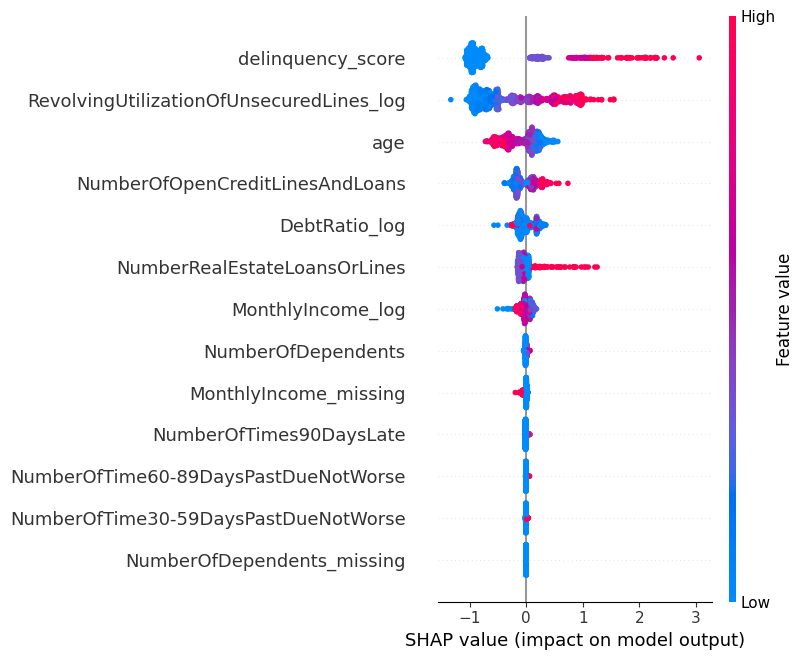

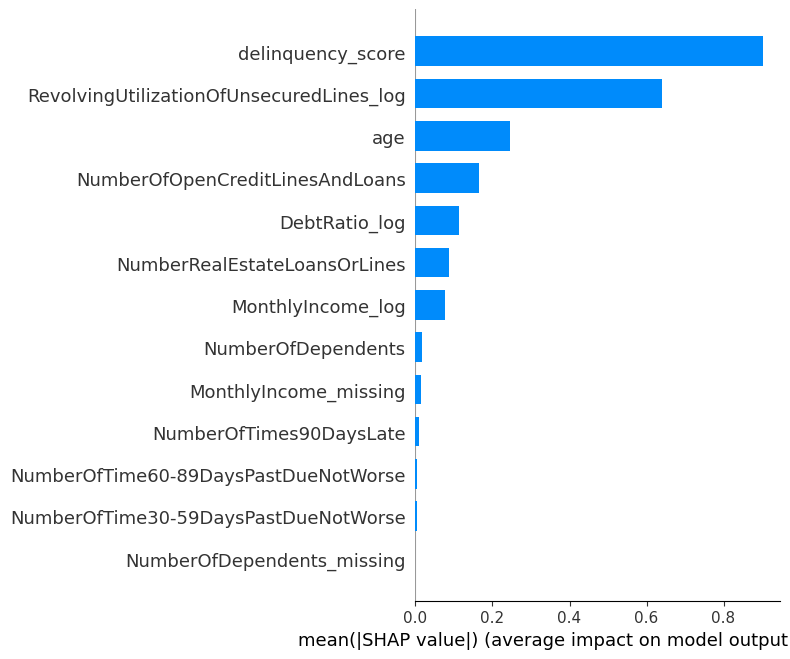

In [ ]:
import shap

# sample test set for speed
X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)

if best_model_name == "XGBoost":
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

elif best_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(
        best_model,
        X_train,
        feature_perturbation="interventional"
    )
    shap_values = explainer.shap_values(X_shap)

# summary plot
shap.summary_plot(shap_values, X_shap)

# bar plot
shap.summary_plot(shap_values, X_shap, plot_type="bar")

### Get PD scores for each borrower

In [85]:
results = X_test_raw.copy().reset_index(drop=True)

results["Actual_Default"] = y_test.reset_index(drop=True)
results["PD"] = y_test_proba

results[["Actual_Default", "PD"]].head()

,Actual_Default,PD
0,0,0.954525
1,1,0.216418
2,1,0.975310
3,0,0.562936
4,0,0.056442


### Construct LGD proxy

In [86]:
results["DebtRatio"] = results["DebtRatio"].fillna(X_train_raw["DebtRatio"].median())
results["RevolvingUtilizationOfUnsecuredLines"] = results["RevolvingUtilizationOfUnsecuredLines"].fillna(
    X_train_raw["RevolvingUtilizationOfUnsecuredLines"].median()
)

results["LGD"] = (
    0.3
    + 0.4 * results["DebtRatio"]
    + 0.3 * results["RevolvingUtilizationOfUnsecuredLines"]
)

# Force LGD into 0 to 1 range
results["LGD"] = results["LGD"].clip(0, 1)

results[["DebtRatio", "RevolvingUtilizationOfUnsecuredLines", "LGD"]].head()

,DebtRatio,RevolvingUtilizationOfUnsecuredLines,LGD
0,0.400660,1.002657,0.761061
1,0.803006,0.000000,0.621202
2,0.296616,1.349256,0.823423
3,1.049507,0.050194,0.734861
4,38.000000,0.027962,1.000000


### Construct EAD proxy

In [87]:
results["MonthlyIncome"] = results["MonthlyIncome"].fillna(X_train_raw["MonthlyIncome"].median())
results["MonthlyIncome"] = results["MonthlyIncome"].clip(lower=0)

results["EAD"] = results["MonthlyIncome"] * 12

# Cap extreme exposure values
results["EAD"] = results["EAD"].clip(upper=results["EAD"].quantile(0.99))

results[["MonthlyIncome", "EAD"]].head()

,MonthlyIncome,EAD
0,10000.0,120000.0
1,8583.0,102996.0
2,2777.0,33324.0
3,4665.0,55980.0
4,5400.0,64800.0


### Compute Expected Loss

In [88]:
results["Expected_Loss"] = results["PD"] * results["LGD"] * results["EAD"]

results[["PD", "LGD", "EAD", "Expected_Loss"]].head()

,PD,LGD,EAD,Expected_Loss
0,0.954525,0.761061,120000.0,87174.189252
1,0.216418,0.621202,102996.0,13846.745234
2,0.975310,0.823423,33324.0,26762.258920
3,0.562936,0.734861,55980.0,23157.786560
4,0.056442,1.000000,64800.0,3657.414803


### Rank borrowers by Expected Loss

In [89]:
top_loss_borrowers = results.sort_values(by="Expected_Loss", ascending=False)

display(
    top_loss_borrowers[
        [
            "Actual_Default",
            "PD",
            "LGD",
            "EAD",
            "Expected_Loss",
            "DebtRatio",
            "RevolvingUtilizationOfUnsecuredLines",
            "MonthlyIncome"
        ]
    ].head(20)
)

,Actual_Default,PD,LGD,EAD,Expected_Loss,DebtRatio,RevolvingUtilizationOfUnsecuredLines,MonthlyIncome
7796,0,0.981790,0.982324,265862.88,256407.743781,1.022866,0.910591,22259.0
10089,1,0.913770,0.847861,265862.88,205977.206621,0.728403,0.854999,23000.0
6466,0,0.809455,0.931727,265862.88,200511.485696,0.995696,0.778162,23000.0
5711,0,0.862852,0.872522,246000.00,185202.755101,0.722843,0.944616,20500.0
12688,1,0.899661,0.730379,265862.88,174696.780149,0.001217,1.432973,45996.0
2622,0,0.950301,0.656438,264000.00,164686.929584,0.515977,0.500159,22000.0
19252,0,0.876487,0.703392,265862.88,163908.083885,0.387677,0.827737,35833.0
18407,0,0.836850,0.807925,225600.00,152530.964328,0.519813,1.000000,18800.0
22214,0,0.788517,0.715291,265862.88,149951.928205,0.308397,0.973110,30583.0
22208,0,0.783649,0.724149,264000.00,149814.388730,0.369165,0.921611,22000.0


In [90]:
top_10pct = results.sort_values("Expected_Loss", ascending=False).head(int(0.1 * len(results)))

print(
    "Top 10% borrowers contribute:",
    round(top_10pct["Expected_Loss"].sum() / results["Expected_Loss"].sum() * 100, 2),
    "% of total expected loss"
)

Top 10% borrowers contribute: 36.87 % of total expected loss


### Compare decision rules

In [91]:
# Rule A: Threshold-based classification
results["Predicted_Default_By_Threshold"] = (results["PD"] >= final_threshold).astype(int)

threshold_summary = (
    results["Predicted_Default_By_Threshold"]
    .value_counts()
    .sort_index()
    .rename_axis("Predicted_Default_By_Threshold")
    .reset_index(name="Count")
)
display(threshold_summary)

,Predicted_Default_By_Threshold,Count
0,0,20671
1,1,1738


In [92]:
# Rule B: Expected Loss-based ranking
loss_cutoff = results["Expected_Loss"].quantile(0.90)

results["High_Expected_Loss_Flag"] = (results["Expected_Loss"] >= loss_cutoff).astype(int)

loss_summary = (
    results["High_Expected_Loss_Flag"]
    .value_counts()
    .sort_index()
    .rename_axis("High_Expected_Loss_Flag")
    .reset_index(name="Count")
)
display(loss_summary)

,High_Expected_Loss_Flag,Count
0,0,20168
1,1,2241


### Compare the two rules

In [93]:
comparison_table = pd.crosstab(
    results["Predicted_Default_By_Threshold"],
    results["High_Expected_Loss_Flag"],
    rownames=["Threshold Rule"],
    colnames=["Expected Loss Rule"]
)

display(comparison_table)

Expected Loss Rule,0,1
Threshold Rule,,
0,19300,1371
1,868,870


### Summary tables for interpretation

In [94]:
# Average profile by threshold rule
threshold_profile = (
    results.groupby("Predicted_Default_By_Threshold")[["PD", "LGD", "EAD", "Expected_Loss"]]
    .mean()
    .round(4)
)
display(threshold_profile)

# Average profile by Expected Loss rule
el_profile = (
    results.groupby("High_Expected_Loss_Flag")[["PD", "LGD", "EAD", "Expected_Loss"]]
    .mean()
    .round(4)
)
display(el_profile)

,PD,LGD,EAD,Expected_Loss
Predicted_Default_By_Threshold,,,,
0,0.2774,0.6213,74794.4924,12833.4545
1,0.8919,0.7625,59898.3861,40474.6235


,PD,LGD,EAD,Expected_Loss
High_Expected_Loss_Flag,,,,
0,0.2816,0.6142,69560.5146,10504.2163
1,0.7156,0.7950,110345.3323,55232.5744


### Expected Loss distribution

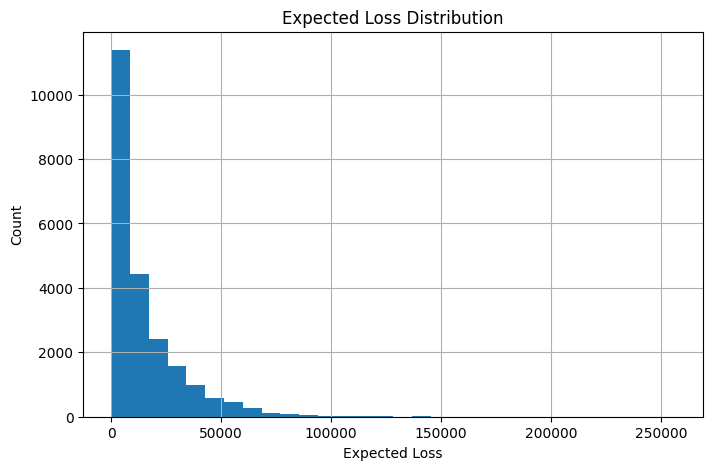

In [95]:
plt.figure(figsize=(8, 5))
plt.hist(results["Expected_Loss"], bins=30)
plt.xlabel("Expected Loss")
plt.ylabel("Count")
plt.title("Expected Loss Distribution")
plt.grid(True)
plt.show()

### PD vs Expected Loss

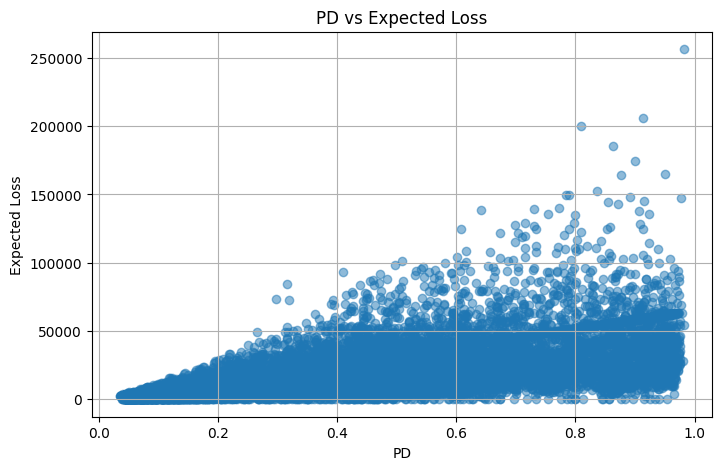

In [96]:
plt.figure(figsize=(8, 5))
plt.scatter(results["PD"], results["Expected_Loss"], alpha=0.5)
plt.xlabel("PD")
plt.ylabel("Expected Loss")
plt.title("PD vs Expected Loss")
plt.grid(True)
plt.show()